# Task 4: Feature Selection

## Libraries

In [ ]:
DATA_PATH = '../data/students_dataset.csv'
##########################
import random, os, warnings, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
##########################
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
warnings.filterwarnings('ignore')
##########################
sys.path.insert(0, '../src')
from script import*
##########################
sns.set_theme(style='whitegrid', font_scale=1.1)
os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)
##########################
with open('../results/winner.json') as f:
    WINNER = json.load(f)['winner']
print(f'Winner algorithm: {WINNER}')
##########################
# Libratied for instantiating the Winner Estimator
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

Winner algorithm: LDA


## Loading Data

In [ ]:
df_raw = pd.read_csv(DATA_PATH) 
df = df_raw.copy()
df['num'] = (df['num'] > 0).astype(int)  
X = df.drop(columns='num')
y = df['num']
print(f'Dataset shape: {X.shape}')
print(f'Class distribution:\n{y.value_counts()}')

Shape: (242, 13)


## Instantiate the Winner Estimator

In [ ]:

winner_clf_map = {
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=SEED,verbose=-1, n_jobs=-1, class_weight='balanced'),
    'XGBoost':  XGBClassifier(n_estimators=100, random_state=SEED,eval_metric='logloss', verbosity=0, n_jobs=-1),
    'CatBoost': CatBoostClassifier(iterations=100, random_seed=SEED, verbose=0),
    'RF':       RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1, class_weight='balanced'),
    'LR':       LogisticRegression(penalty='elasticnet', solver='saga',l1_ratio=0.5, max_iter=10000, random_state=SEED),
    'LDA':      LinearDiscriminantAnalysis(),
    'GNB':      GaussianNB(),
}

winner_clf = winner_clf_map[WINNER]
print(f'Using: {WINNER}')

Using: LDA


## Define Hyperparameter Space for the Winner

In [ ]:
def lgbm_space(trial):
    return {
        'n_estimators':  trial.suggest_int('n_estimators', 50, 500, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':     trial.suggest_int('max_depth', 3, 10),
        'num_leaves':    trial.suggest_int('num_leaves', 15, 63),
        'reg_alpha':     trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
        'reg_lambda':    trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
        'class_weight':  'balanced',
        'random_state':  SEED,
        'verbose':      -1,
        'n_jobs':       -1,
    }

def xgb_space(trial):
    return {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500, step=50),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
        'eval_metric':      'logloss',
        'verbosity':        0,
        'random_state':     SEED,
        'n_jobs':          -1,
    }

def rf_space(trial):
    return {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth':        trial.suggest_int('max_depth', 3, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight':     'balanced',
        'random_state':     SEED,
        'n_jobs':          -1,
    }

def catboost_space(trial):
    return {
        'iterations':    trial.suggest_int('iterations', 50, 500, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth':         trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_seed':   SEED,
        'verbose':       0,
    }

def lr_space(trial):
    return {
        'C':        trial.suggest_float('C', 1e-3, 10.0, log=True),
        'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0),
        'max_iter': 10000,
        'penalty':  'elasticnet',
        'solver':   'saga',
        'random_state': SEED,
    }

space_map = {'LightGBM': lgbm_space,'XGBoost':  xgb_space,'RF': rf_space,'CatBoost': catboost_space,'LR': lr_space,'LDA': lambda trial: {},
             'GNB': lambda trial: {'var_smoothing': trial.suggest_float('var_smoothing', 1e-11, 1e-6, log=True)},}

winner_param_space = space_map[WINNER]
print(f'Param space loaded for: {WINNER}')

Param space loaded for: LDA


## rnCV with Feature Selection Enabled



In [ ]:
#Setting `feature_selection=True` 
rncv_fs = RepeatedNestedCV( estimators=[(WINNER, winner_clf)],param_spaces={WINNER: winner_param_space},
    n_repeats=10, n_outer=5, n_inner=3, n_trials=50, base_seed=SEED,tune=True,
    feature_selection=True, fs_n_features=None,inner_metric='roc_auc',)
rncv_fs.fit(X, y)
print('rnCV with feature selection complete.')

rnCV with feature selection complete.


## Feature Selection Frequency



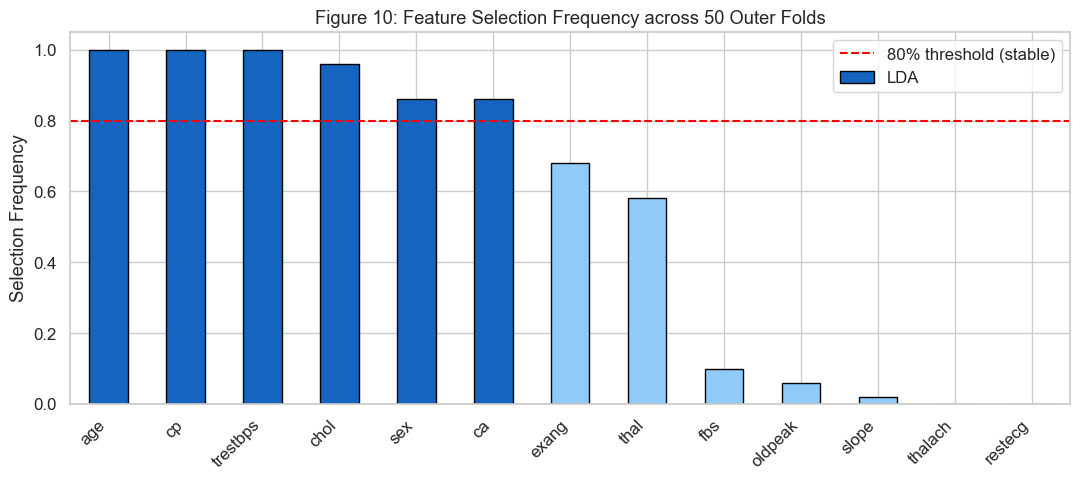

Stable features (>=80%): ['age', 'cp', 'trestbps', 'chol', 'sex', 'ca']
Count: 6 / 13


In [ ]:
#Features selected in **>=80%** of the 50 outer folds are considered stable.

freq_df = rncv_fs.feature_selection_report()
freq_series = freq_df.loc[WINNER].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#1565C0' if v >= 0.8 else '#90CAF9' for v in freq_series.values]
freq_series.plot(kind='bar', ax=ax, color=colors, edgecolor='black')

ax.axhline(0.8, color='red', linestyle='--', linewidth=1.5, label='80% threshold (stable)')
ax.set_ylabel('Selection Frequency')
ax.set_ylim(0, 1.05)
ax.legend()


plt.suptitle('') 
plt.xticks(rotation=45, ha='right')
plt.savefig('../figures/feature_selection_freq.png', bbox_inches='tight')
plt.show()

#Saving the stable features for later use 
stable_features = freq_series[freq_series >= 0.8].index.tolist()

## Re-run rnCV on Stable Features Only

In [ ]:
X_stable = X[stable_features]
print(f'Stable feature matrix: {X_stable.shape}')

rncv_stable = RepeatedNestedCV( estimators=[(WINNER, winner_clf)],param_spaces={WINNER: winner_param_space},
    n_repeats=10, n_outer=5, n_inner=3,n_trials=50,
    base_seed=SEED, tune=True, feature_selection=False,inner_metric='roc_auc',)

rncv_stable.fit(X_stable, y)
print('rnCV on stable features complete.')

Stable feature matrix: (242, 6)
rnCV on stable features complete.


---

## Performance Comparison

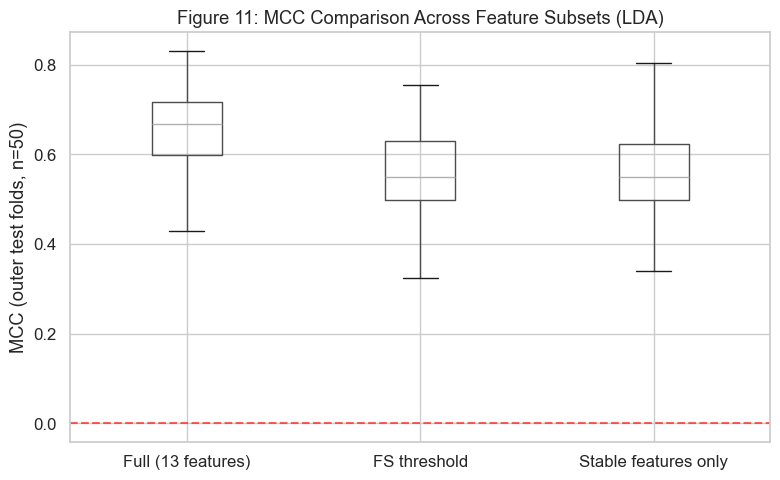

Medians:
Full (13 features)      0.6683
FS threshold            0.5498
Stable features only    0.5488


In [ ]:
with open('../results/rncv_results.json') as f:
    all_results = json.load(f)

full_mcc   = pd.DataFrame(all_results[WINNER])['MCC'].values
fs_mcc     = rncv_fs.get_fold_results(WINNER)['MCC'].values
stable_mcc = rncv_stable.get_fold_results(WINNER)['MCC'].values

compare_df = pd.DataFrame({'Full (13 features)':   full_mcc,'FS threshold': fs_mcc,'Stable features only': stable_mcc,})

fig, ax = plt.subplots(figsize=(8, 5))
compare_df.boxplot(ax=ax)
ax.axhline(0, color='red', linestyle='--', alpha=0.6)
ax.set_ylabel('MCC (outer test folds, n=50)')

plt.suptitle('') 
plt.savefig('../figures/fs_comparison.png', bbox_inches='tight')
plt.show()

## Full Metric Summary

In [ ]:
key_cols = ['MCC_median', 'AUC_median', 'BA_median','F1_median', 'Recall_median', 'Specificity_median']

print(' rnCV with FS:')
display(rncv_fs.summary()[key_cols])

print('rnCV with Stable Features Only:')
display(rncv_stable.summary()[key_cols])

=== rnCV with FS (threshold) ===


,MCC_median,AUC_median,BA_median,F1_median,Recall_median,Specificity_median
Estimator,,,,,,
LDA,0.5498,0.8504,0.7756,0.7556,0.6887,0.8462



=== rnCV with Stable Features Only ===


,MCC_median,AUC_median,BA_median,F1_median,Recall_median,Specificity_median
Estimator,,,,,,
LDA,0.5488,0.8619,0.7722,0.7578,0.7391,0.8113


## Saving Stable Features 

In [11]:
with open('../results/stable_features.json', 'w') as f:
    json.dump({'stable_features': stable_features}, f, indent=2)
print(f'Saved: {stable_features}')

Saved: ['age', 'cp', 'trestbps', 'chol', 'sex', 'ca']
